


# Labor-Experiment
In diesem Experiment wurden vier Accesspoint in einem Raum aufgestellt. Am besten werden die Accesspoints so platziert und fixiert, dass sie in der Position nicht veränder werden können. Wir haben jedem Accesspoint eine eigene ESSID vergeben, um die Accesspoint leicht auseinander zu halten und in der Auswertung leicht verschiedene Szenarien testen zu können.

## 1. Training - Daten aufnehmen

Ein RaspberryPi (im Folgenden "Rover") wurde ein USB-WLAN-Stick angeschlossen, um eine bessere Antenne zu haben. Auf den Rover haben wir die Skripte unter rover/ kopiert.
Mit dem Skript "train_labor.py" können nun Strukturiert Daten erfasst werden. Zum Trainieren ist es wichtig die Koordinaten des Punktes an dem gemessen wird zu kennen. An jedem Punkt werden nun 5 aufeinanderfolgende Messungen durchgeführt. Zum starten einer Messung muss folgender Befehl ausgeführt werden:
```bash
sudo python3 train_labor.py [sensor_id] [project_id] [x-Position] [y-Position]
```

Der Parameter ```sensor_id``` muss eine Ganzzahl (int) sein. Sie kann zum auseinanderhalten mehrere Rover verwendet werden, hat aber sonst keinen Einfluss auf Messungen oder eine spätere Auswertung.

Der Parameter ```project_id``` muss eine Ganzzahl (int) sein. Sie kann zum auseinanderhalten mehrere Projekte/Versuche verwendet werden, hat aber sonst keinen Einfluss auf Messung. Wir haben diesen Parameter für verschiedene Versuche verwendet, um die Daten auseinander zuhalten.

## 2. Daten auswerten
Im Anschluss müssen alle CSV-Dateien auf den PC kopiert werden auf dem die Auswertung durchgeführt wird.
z.B.:
```bash
scp pi@[IP des Rovers]:/home/pi/\*.csv ./data/
```

In [1]:
import pandas as pd
import glob
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from metrics import print_metrics
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

Die Variable ```trainingsdatensatz``` enthält den Prefix der Dateien, die zum Training verwendet werden sollen.

Die Variable ```essid_whitelist``` wird zum filtern der aufgenommenen Daten verwendet, damit ausschließlich die Daten der Test-Accesspoints verwendet werden.

In [2]:
trainingsdatensatz = 'data_train_2_'
essid_whitelist = ['19BC','1209','1B45','1AD3']

### Daten einlesen
Alle Daten werden aus dem ```data/``` Verzeichnis mit dem angegebenen Präfix eingelesen und zu einem Dataframe zusammengeführt.

In [3]:
dateipfad = './data/' + trainingsdatensatz + '*.csv'
dateien = glob.glob(dateipfad)
dfs = []

for datei in dateien:
    df = pd.read_csv(datei)
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

data.head()

,bssid,essid,rssi,point
0,18:D6:C7:0F:63:8A,19BC,-31,1
1,E6:5F:01:D1:0F:68,main,-38,1
2,F4:2E:7F:1B:49:21,eduroam-IPv6only,-61,1
3,F4:2E:7F:1B:49:23,mwn-events,-61,1
4,F4:2E:7F:1B:49:25,HM-iotroam,-62,1


### Daten filtern
Die Daten werden anhand der ESSIDs gefiltert.

In [4]:
data = data.loc[data['essid'].isin(essid_whitelist)]
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 280 entries, 0 to 2004
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   bssid   280 non-null    object
 1   essid   280 non-null    object
 2   rssi    280 non-null    int64 
 3   point   280 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 10.9+ KB


### Points ersetzten
In dem ersten Datensatz wurden nur Punktnummern erfasst. Dieser Schritt muss in Zukunft nicht mehr ausgeführt werden, da die Koordinaten beim Datenerfassen mit angegeben werden.

In [5]:
p = 12

x = ((p-1)%4) * 1.6
y = (int((p-1)/4)) * 2.0
data['position_x'] = ((data['point']-1)%4) * 1.6
data['position_y'] = (np.int64((data['point']-1)/4)) * 2.0

data.head()

,bssid,essid,rssi,point,position_x,position_y
0,18:D6:C7:0F:63:8A,19BC,-31,1,0.0,0.0
5,18:D6:C7:0A:8A:1F,1209,-36,1,0.0,0.0
6,60:E3:27:1C:2C:A4,1B45,-27,1,0.0,0.0
7,18:D6:C7:0C:AB:C7,1AD3,-43,1,0.0,0.0
27,18:D6:C7:0F:63:8A,19BC,-33,1,0.0,0.0


### Spalten entfernen
Alle nicht mehr benötigten Spalten werden aus dem Dataframe entfernt.

In [6]:
data.drop('essid', axis=1, inplace=True)
data.drop('point', axis=1, inplace=True)
data.head()

,bssid,rssi,position_x,position_y
0,18:D6:C7:0F:63:8A,-31,0.0,0.0
5,18:D6:C7:0A:8A:1F,-36,0.0,0.0
6,60:E3:27:1C:2C:A4,-27,0.0,0.0
7,18:D6:C7:0C:AB:C7,-43,0.0,0.0
27,18:D6:C7:0F:63:8A,-33,0.0,0.0


### Daten umwandeln
Aus die Daten aus jeder Messung (n-Datensätze je Messung) werden in einen Datensatz umgewandelt. Die Spalten werden dynamisch aus den bssids zusammengestellt und um die x- und y-Position ergänzt.

In [7]:
df = pd.DataFrame(columns=np.append(data['bssid'].unique(), ['position_x','position_y']))
a = 0
for i, row in data.iterrows():
    epoch = int(a/4)
    a += 1

    df.loc[epoch, row['bssid']] = row['rssi']
    df.loc[epoch, 'position_x'] = row['position_x']
    df.loc[epoch, 'position_y'] = row['position_y']

df.head()

,18:D6:C7:0F:63:8A,18:D6:C7:0A:8A:1F,60:E3:27:1C:2C:A4,18:D6:C7:0C:AB:C7,position_x,position_y
0,-31,-36,-27,-43,0.0,0.0
1,-33,-40,-26,-44,0.0,0.0
2,-33,-39,-25,-41,0.0,0.0
3,-30,-38,-26,-43,0.0,0.0
4,-34,-37,-25,-43,0.0,0.0


### Modell trainieren
Jetzt können mit den Daten ein Modell trainiert werden. Dafür wird der Datensatz in die Eingabefeatures X und die Ausgabefeatures Z getrennt. Im Anschluss werden die Daten in einen Trainings und einen Testdatensatz zufällig geteilt.

In [8]:
X = df.iloc[:, 0:-2]
y = df.iloc[:, -2:]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=0)

regr = RandomForestRegressor(random_state=0)
regr.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Modell testen
Mit den Testdaten wird nun das Modell geprüft.

In [9]:
y_pred = regr.predict(X_test)

print_metrics(y_pred, y_test)

RMSE: 0.7753520000000005
RMSE X: 0.42710453722044067 RMSE Y: 1.1697374552803352
MAE X: 0.35200000000000004 MAE Y: 0.7742857142857142
Mean Position Error: 0.9284484429236901
Median Position Error: 0.4828084506302682


### Darstellen der Testdaten
Die Testdaten werden nun in einem Plot dargestellt.

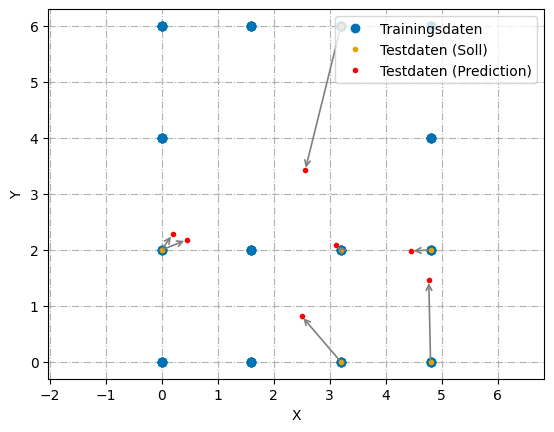

In [10]:
blue = "#0072B2"
red = "#E69F00"

fig, ax = plt.subplots()

ax.grid(True, linestyle='-.')
ax.axis('equal')

ax.plot(y_train.loc[:, 'position_x'],y_train.loc[:, 'position_y'], 'o', color=blue, label="Trainingsdaten")
ax.plot(y_test.loc[:, 'position_x'],y_test.loc[:, 'position_y'], '.', color=red, label="Testdaten (Soll)")
ax.plot(y_pred[:,0],y_pred[:,1], 'r.', label="Testdaten (Prediction)")
index = 0
for _, row in y_test.iterrows():
    plt.annotate(
        "",  # kein Text, nur Pfeil
        xy=(y_pred[index, 0], y_pred[index, 1]),   # Pfeilspitze
        xytext=(row["position_x"], row["position_y"]),               # Startpunkt
        arrowprops=dict(
            arrowstyle="->",
            color="gray",
            lw=1.2
        )
    )
    index += 1


ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend(loc="upper right")

plt.show()